<a href="https://www.kaggle.com/code/lalit7881/google-play-store-apps-eda-100?scriptVersionId=335844900" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashyou09/google-play-store-apps-2026-edition/google_playstore_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ashyou09/google-play-store-apps-2026-edition/google_playstore_2026.csv")

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,In-App Purchases,Ad Supported
0,Strike Plus,FAMILY,4.6,12460594,Varies with device,"500,000,000+",Free,0.00,Teen,Family,"January 15, 2026",Varies with device,8.0 and up,Yes,Yes
1,Tracker AI,EDUCATION,3.4,11487705,Varies with device,"500,000,000+",Free,0.00,Everyone,Education,"October 22, 2025",Varies with device,11.0 and up,Yes,Yes
2,Scanner,FAMILY,3.5,10503932,Varies with device,"500,000,000+",Paid,0.99,Everyone,Family,"November 08, 2024",Varies with device,10.0 and up,No,No
3,Connect 3D,ART_AND_DESIGN,4.7,4818860,221.6M,"100,000,000+",Free,0.00,Everyone,Art And Design,"October 07, 2025",6.8.21,10.0 and up,No,Yes
4,VPN,PRODUCTIVITY,3.5,3562800,122.9M,"100,000,000+",Free,0.00,Everyone,Productivity,"June 29, 2026",5.5.11,12.0 and up,Yes,Yes


In [4]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,In-App Purchases,Ad Supported
11495,Epic Learn Plus,PRODUCTIVITY,NaN,0,74.3M,10+,Free,0.0,Everyone,Productivity,"August 16, 2024",8.8.45,11.0 and up,Yes,Yes
11496,Scanner Pro,PHOTOGRAPHY,NaN,0,34.8M,10+,Free,0.0,Everyone,Photography,"September 10, 2024",7.9.59,11.0 and up,Yes,Yes
11497,Dash 2023,WEATHER,NaN,0,34.4M,10+,Free,0.0,Everyone,Weather,"November 13, 2025",2.3.74,9.0 and up,Yes,Yes
11498,Pro Strike,BOOKS_AND_REFERENCE,NaN,0,81.1M,10+,Free,0.0,Everyone,Books And Reference,"October 30, 2025",2.7.72,12.0 and up,Yes,No
11499,Health,FINANCE,NaN,0,139.0M,10+,Free,0.0,Everyone,Finance,"December 01, 2025",15.15.37,10.0 and up,No,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               11500 non-null  object 
 1   Category          11500 non-null  object 
 2   Rating            6123 non-null   float64
 3   Reviews           11500 non-null  int64  
 4   Size              11500 non-null  object 
 5   Installs          11500 non-null  object 
 6   Type              11500 non-null  object 
 7   Price             11500 non-null  float64
 8   Content Rating    11500 non-null  object 
 9   Genres            11500 non-null  object 
 10  Last Updated      11500 non-null  object 
 11  Current Ver       11500 non-null  object 
 12  Android Ver       11500 non-null  object 
 13  In-App Purchases  11500 non-null  object 
 14  Ad Supported      11500 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 1.3+ MB


In [6]:
df.describe()

,Rating,Reviews,Price
count,6123.000000,1.150000e+04,11500.000000
mean,4.057211,8.550739e+03,0.217415
std,0.586312,2.045769e+05,4.169775
min,1.900000,0.000000e+00,0.000000
25%,3.600000,2.000000e+00,0.000000
50%,4.100000,5.000000e+00,0.000000
75%,4.500000,4.500000e+01,0.000000
max,5.000000,1.246059e+07,399.990000


In [7]:
df.isnull().sum()

App                    0
Category               0
Rating              5377
Reviews                0
Size                   0
Installs               0
Type                   0
Price                  0
Content Rating         0
Genres                 0
Last Updated           0
Current Ver            0
Android Ver            0
In-App Purchases       0
Ad Supported           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

App                  object
Category             object
Rating              float64
Reviews               int64
Size                 object
Installs             object
Type                 object
Price               float64
Content Rating       object
Genres               object
Last Updated         object
Current Ver          object
Android Ver          object
In-App Purchases     object
Ad Supported         object
dtype: object

In [10]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'In-App Purchases', 'Ad Supported'],
      dtype='object')

In [11]:
df.shape

(11500, 15)

In [12]:
df.nunique()

App                 2377
Category              36
Rating                32
Reviews             1577
Size                2821
Installs              16
Type                   2
Price                  9
Content Rating         6
Genres                79
Last Updated        1399
Current Ver         8411
Android Ver           10
In-App Purchases       2
Ad Supported           2
dtype: int64

## EDA

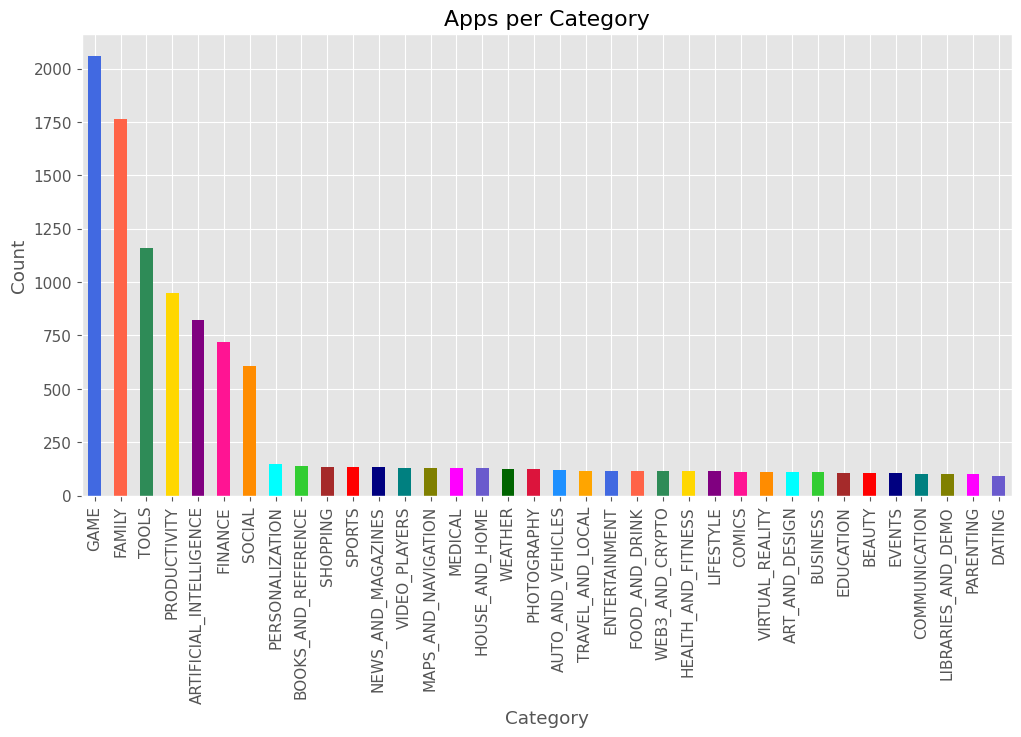

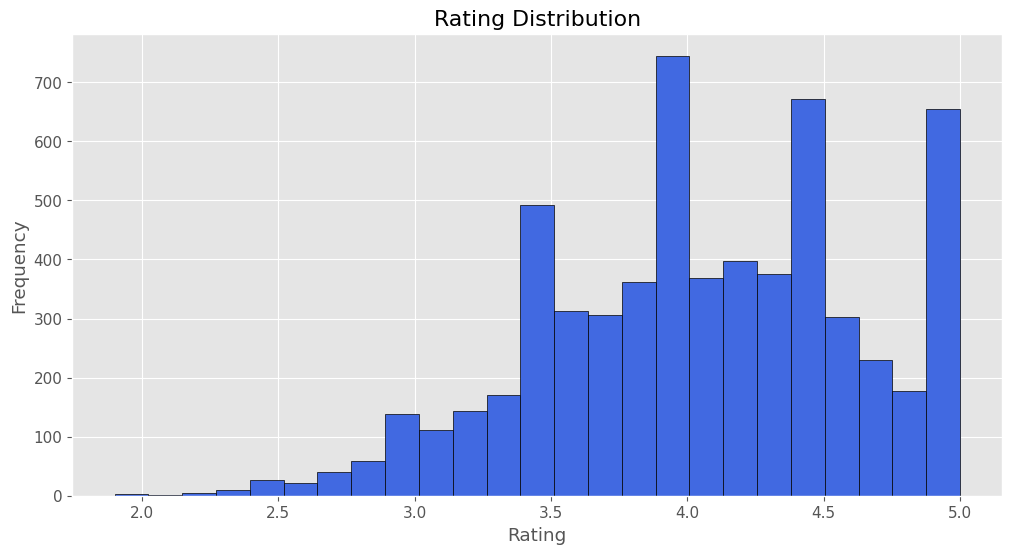

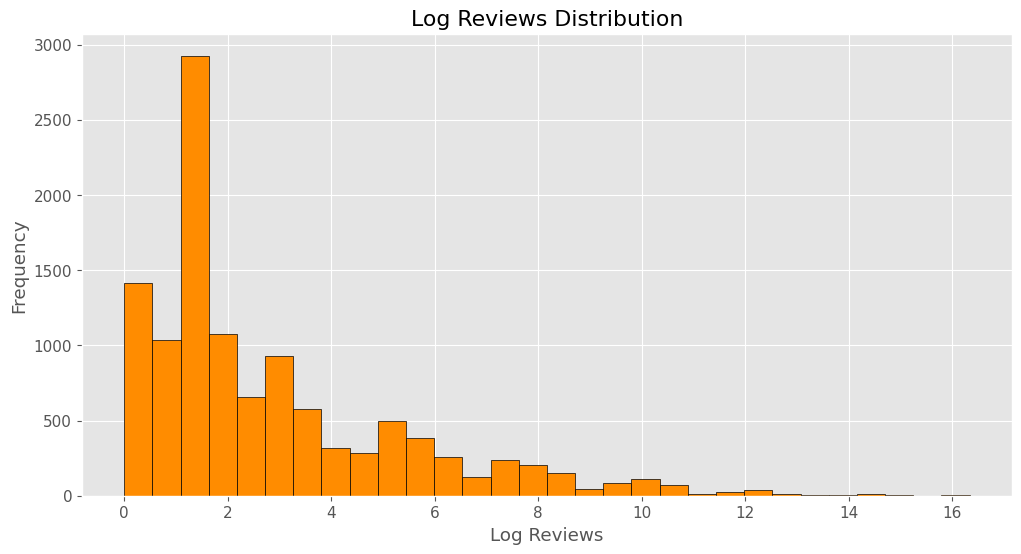

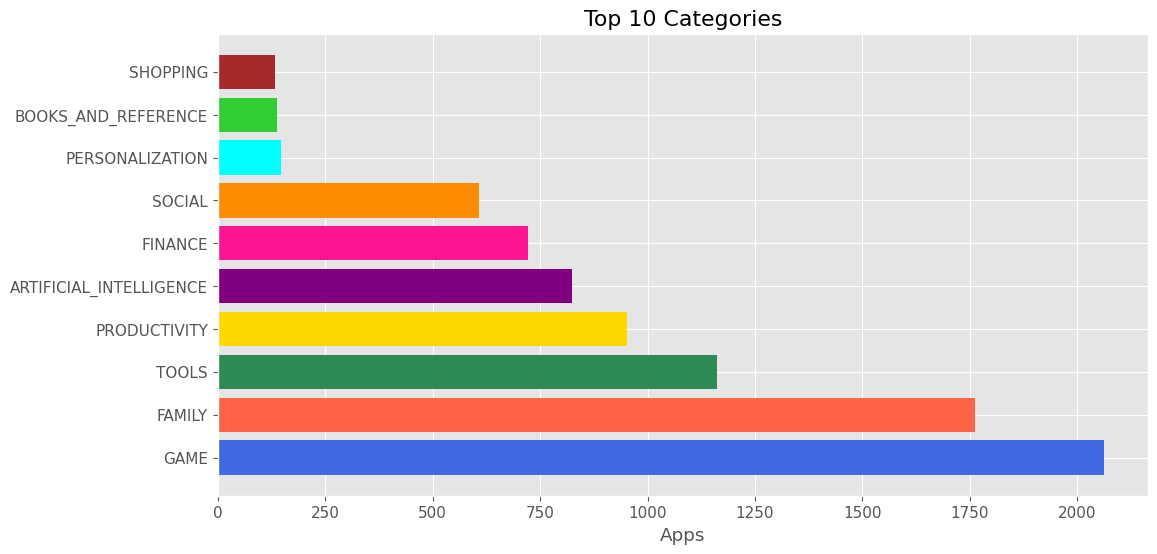

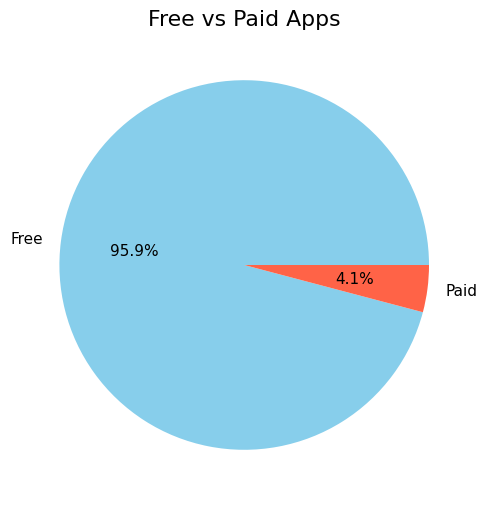

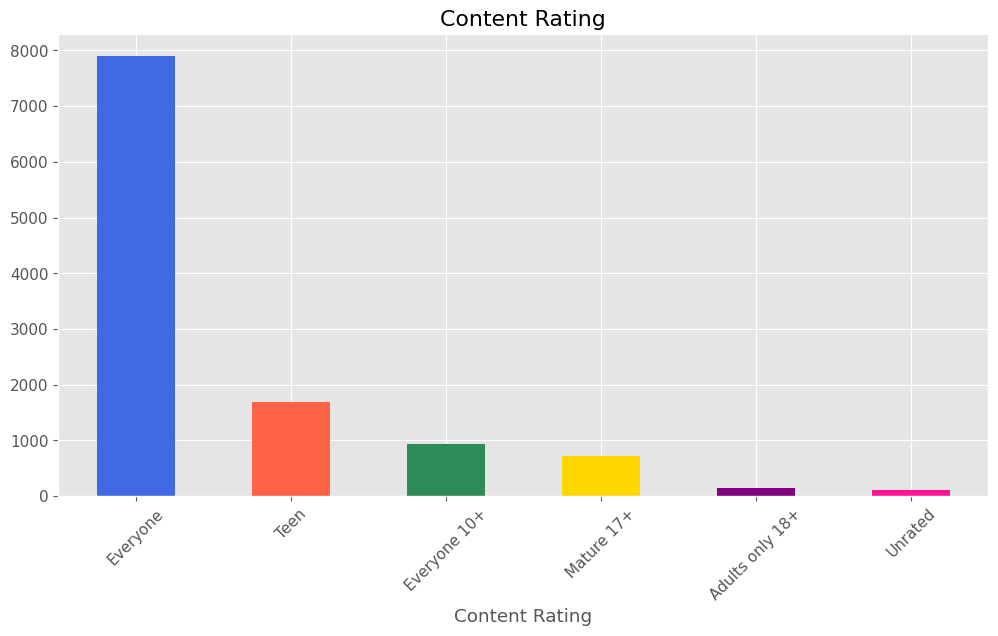

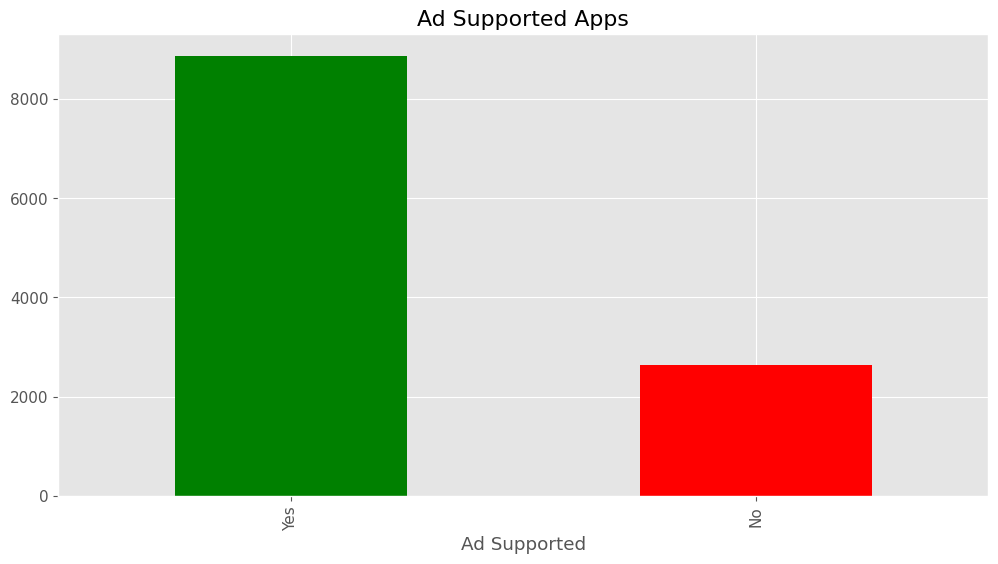

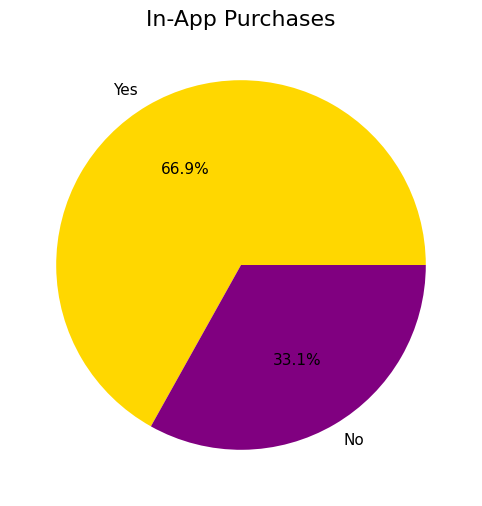

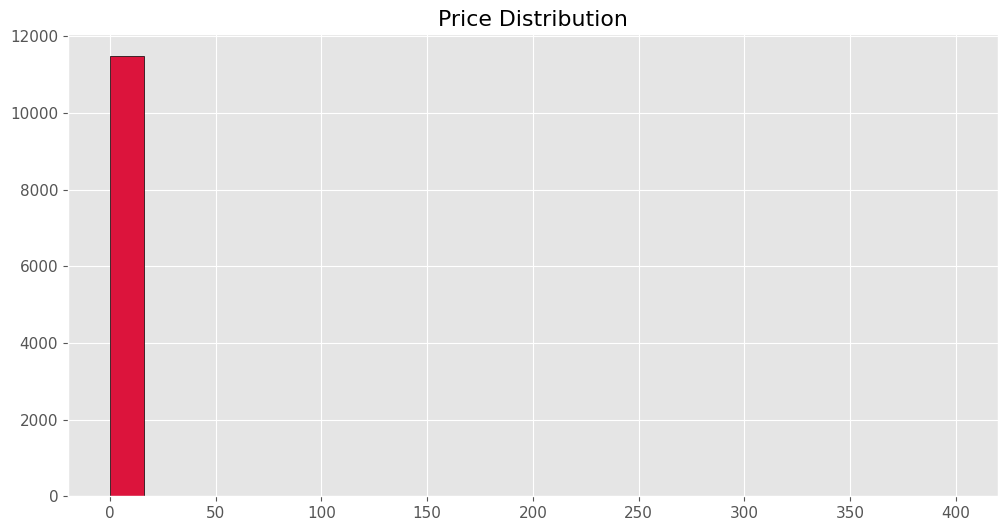

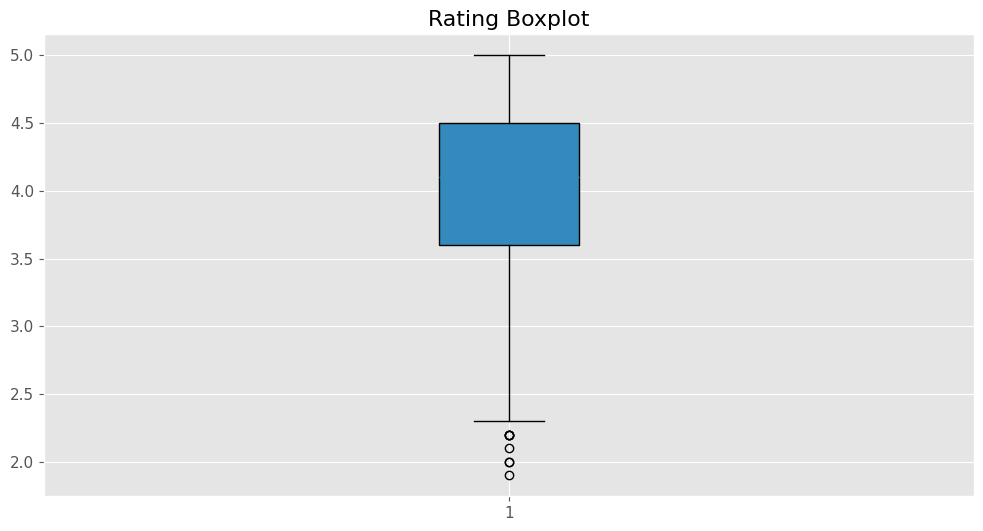

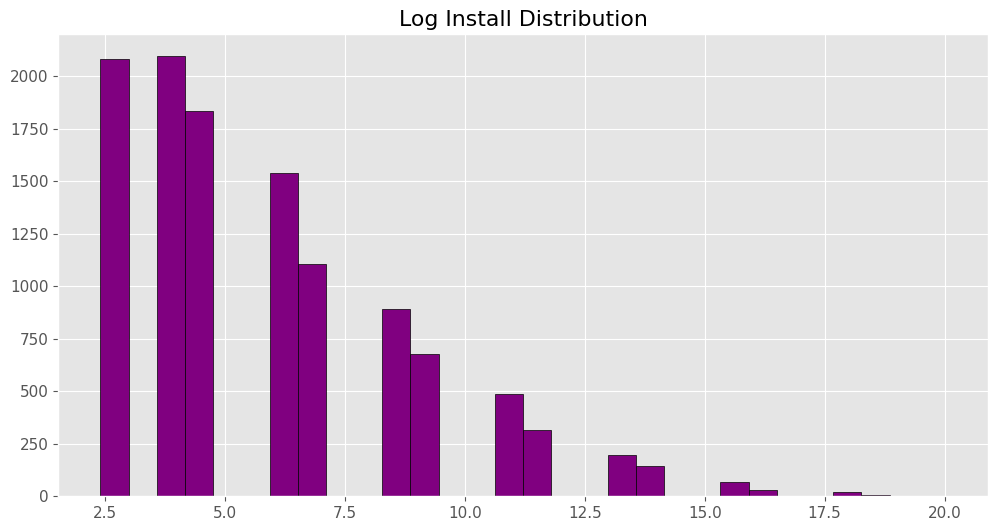

<Figure size 1200x600 with 0 Axes>

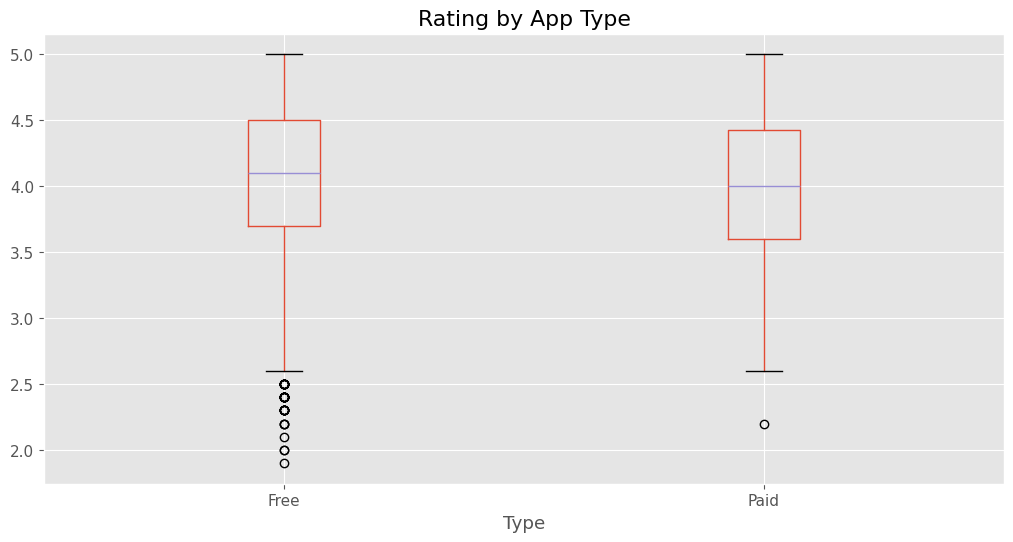

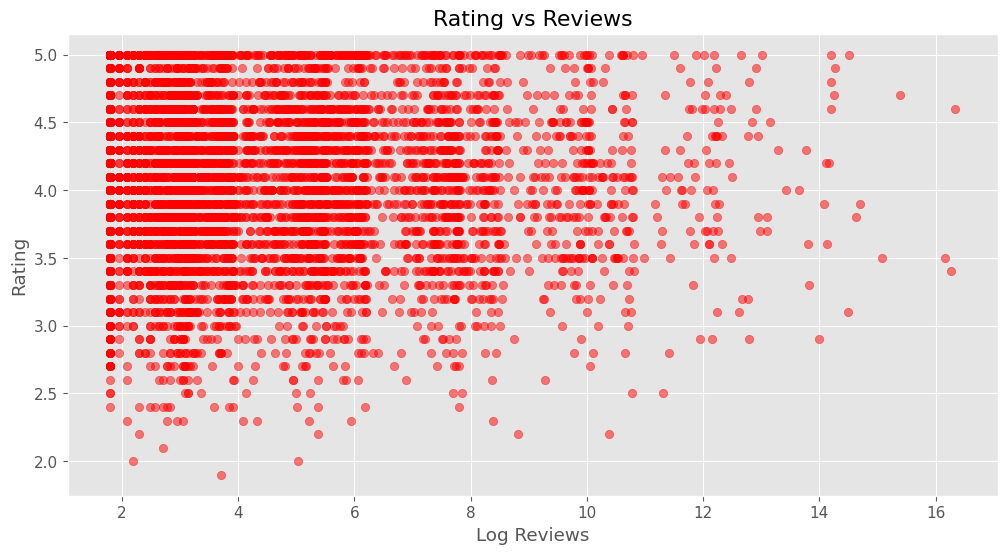

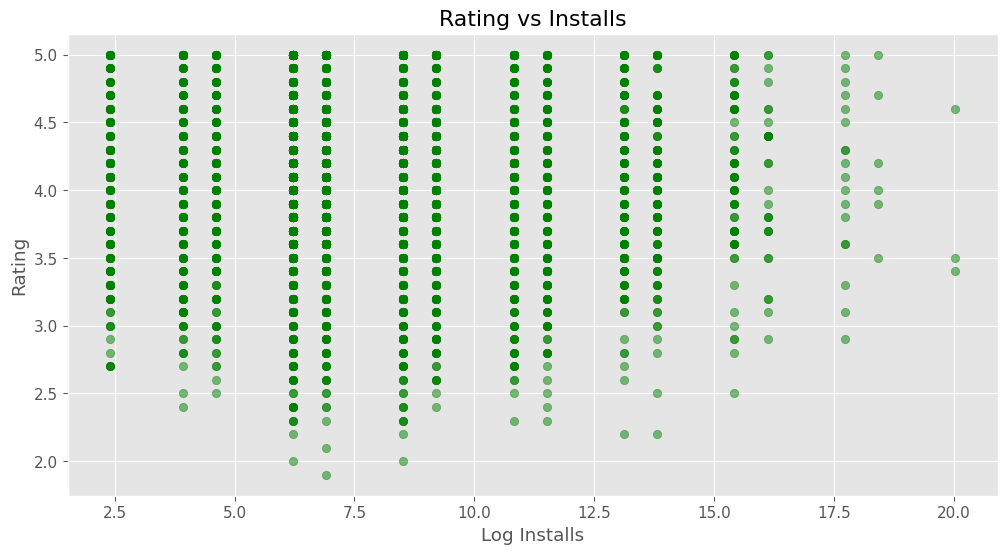

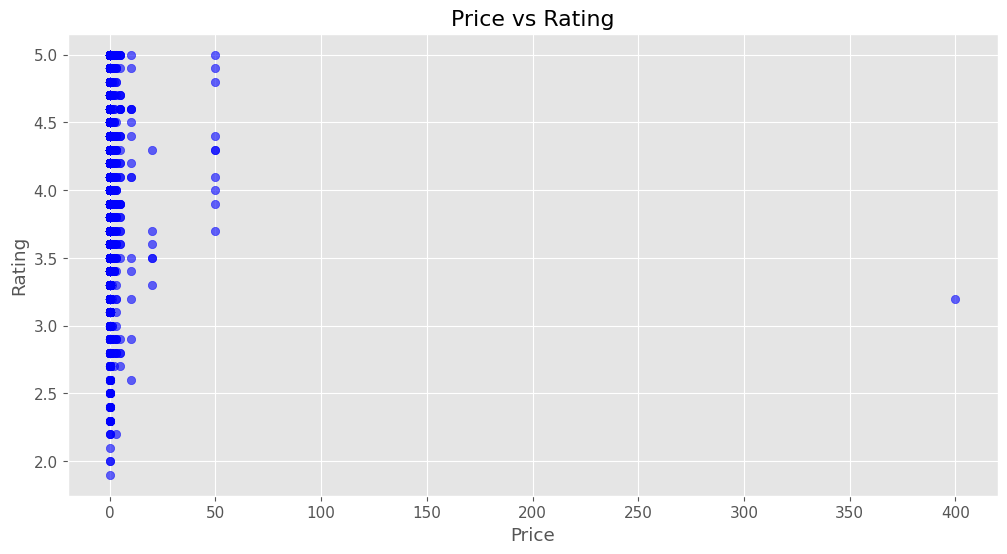

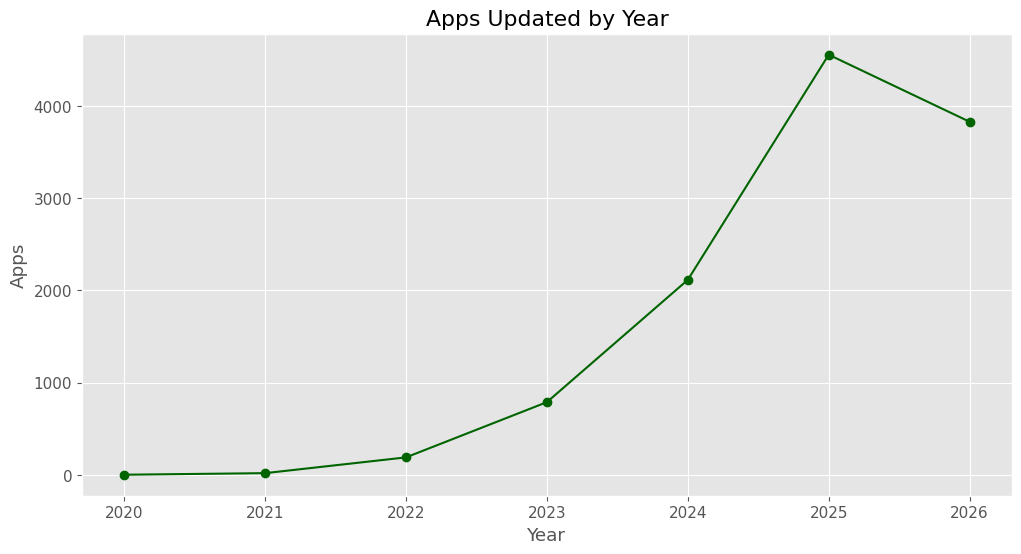

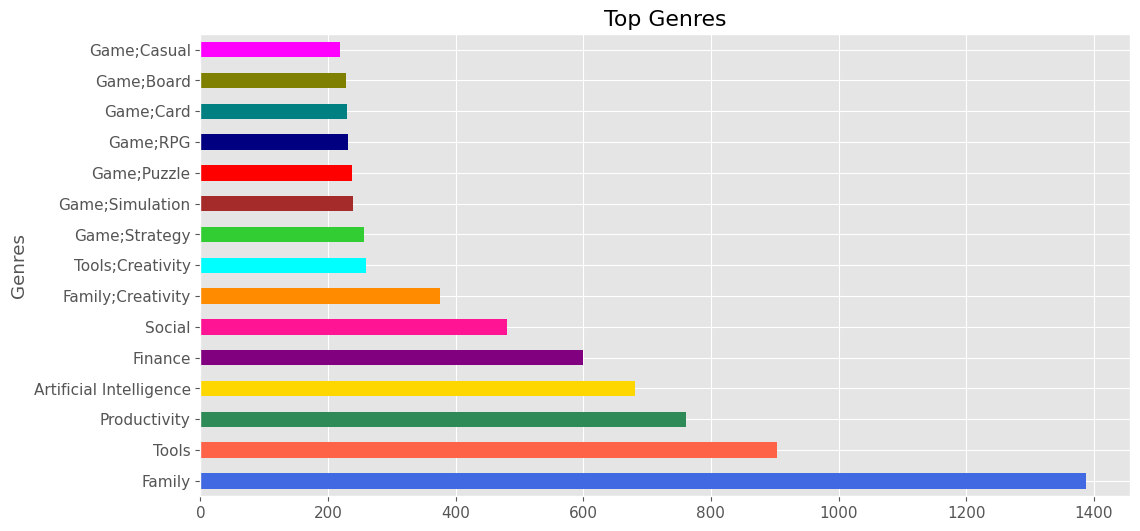

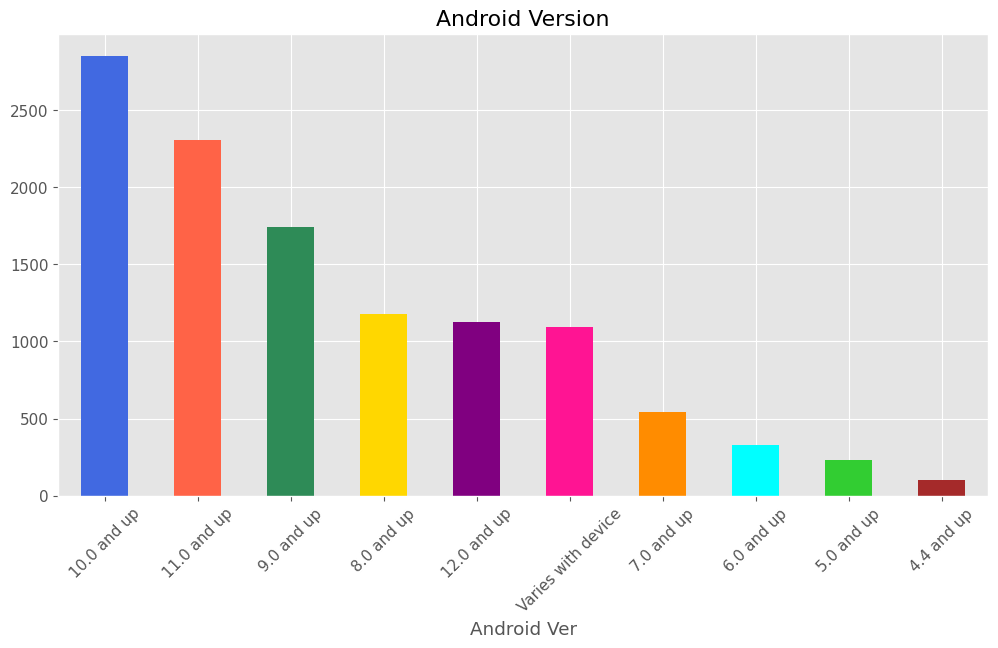

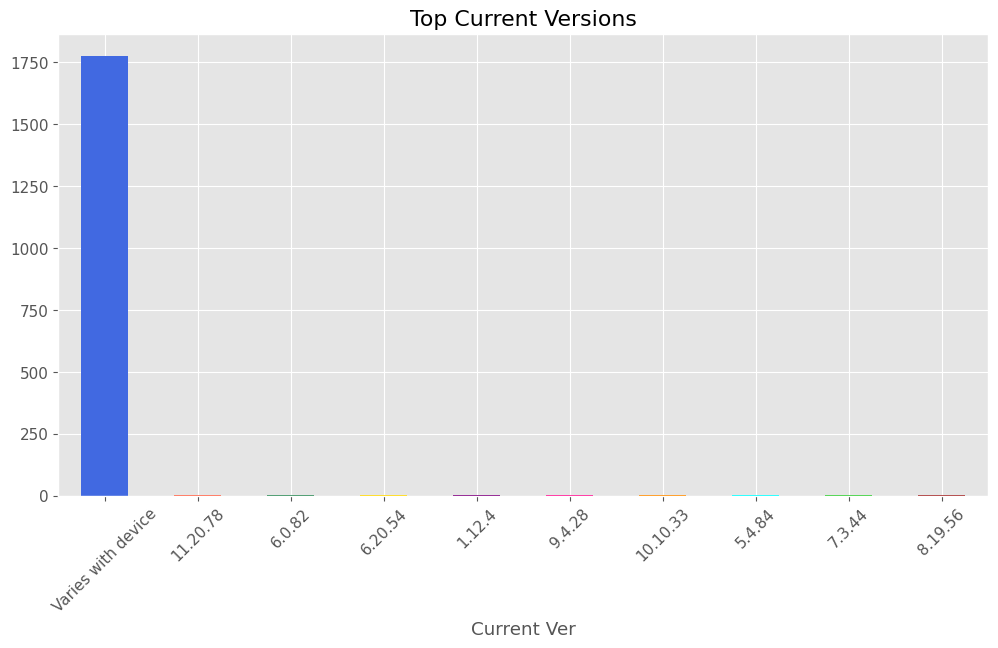

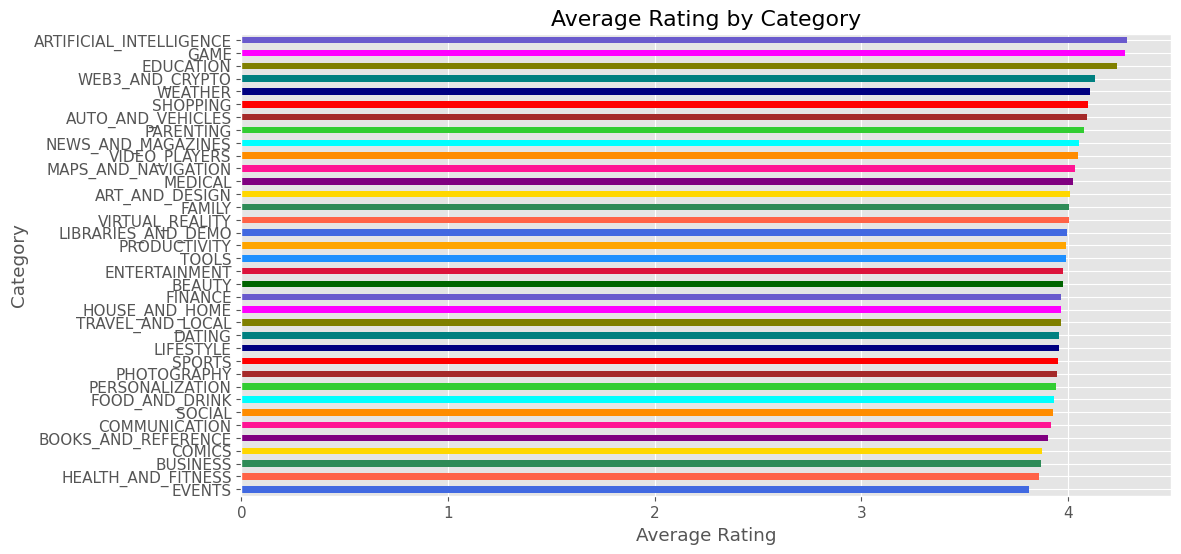

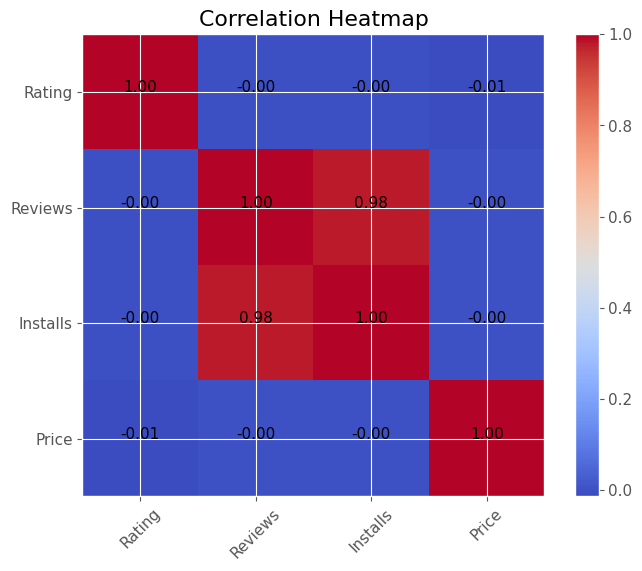

All Visualizations Completed Successfully!


In [13]:
import matplotlib.colors as mcolors

# ----------------------------------------------------------
# Basic Data Cleaning
# ----------------------------------------------------------

df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# ----------------------------------------------------------
# Color Palette
# ----------------------------------------------------------

colors = [
    "royalblue",
    "tomato",
    "seagreen",
    "gold",
    "purple",
    "deeppink",
    "darkorange",
    "cyan",
    "limegreen",
    "brown",
    "red",
    "navy",
    "teal",
    "olive",
    "magenta",
    "slateblue",
    "darkgreen",
    "crimson",
    "dodgerblue",
    "orange"
]

plt.style.use("ggplot")

# ==========================================================
# Figure Size
# ==========================================================

plt.rcParams["figure.figsize"]=(12,6)
plt.rcParams["font.size"]=11

# ==========================================================
# 1 Category Distribution
# ==========================================================

plt.figure()
df['Category'].value_counts().plot(
    kind='bar',
    color=colors
)
plt.title("Apps per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

# ==========================================================
# 2 Rating Distribution
# ==========================================================

plt.figure()
plt.hist(df['Rating'].dropna(),
         bins=25,
         color='royalblue',
         edgecolor='black')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# ==========================================================
# 3 Reviews Distribution
# ==========================================================

plt.figure()
plt.hist(np.log1p(df['Reviews'].dropna()),
         bins=30,
         color='darkorange',
         edgecolor='black')
plt.title("Log Reviews Distribution")
plt.xlabel("Log Reviews")
plt.ylabel("Frequency")
plt.show()

# ==========================================================
# 4 Top Categories
# ==========================================================

plt.figure()

top=df['Category'].value_counts().head(10)

plt.barh(
    top.index,
    top.values,
    color=colors
)

plt.title("Top 10 Categories")
plt.xlabel("Apps")
plt.show()

# ==========================================================
# 5 Free vs Paid
# ==========================================================

plt.figure()

df['Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','tomato']
)

plt.title("Free vs Paid Apps")
plt.ylabel("")
plt.show()

# ==========================================================
# 6 Content Rating
# ==========================================================

plt.figure()

df['Content Rating'].value_counts().plot(
    kind='bar',
    color=colors
)

plt.title("Content Rating")
plt.xticks(rotation=45)
plt.show()

# ==========================================================
# 7 Ad Supported
# ==========================================================

plt.figure()

df['Ad Supported'].value_counts().plot(
    kind='bar',
    color=['green','red']
)

plt.title("Ad Supported Apps")
plt.show()

# ==========================================================
# 8 In-App Purchases
# ==========================================================

plt.figure()

df['In-App Purchases'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['gold','purple']
)

plt.title("In-App Purchases")
plt.ylabel("")
plt.show()

# ==========================================================
# 9 Price Distribution
# ==========================================================

plt.figure()

plt.hist(
    df['Price'].dropna(),
    bins=25,
    color="crimson",
    edgecolor='black'
)

plt.title("Price Distribution")
plt.show()

# ==========================================================
# 10 Rating Boxplot
# ==========================================================

plt.figure()

plt.boxplot(
    df['Rating'].dropna(),
    patch_artist=True
)

plt.title("Rating Boxplot")
plt.show()

# ==========================================================
# 11 Installs Distribution
# ==========================================================

plt.figure()

plt.hist(
    np.log1p(df['Installs'].dropna()),
    bins=30,
    color='purple',
    edgecolor='black'
)

plt.title("Log Install Distribution")
plt.show()

# ==========================================================
# 12 Rating by Type
# ==========================================================

plt.figure()

df.boxplot(
    column='Rating',
    by='Type'
)

plt.title("Rating by App Type")
plt.suptitle("")
plt.show()

# ==========================================================
# 13 Rating vs Reviews
# ==========================================================

plt.figure()

plt.scatter(
    np.log1p(df['Reviews']),
    df['Rating'],
    color='red',
    alpha=0.5
)

plt.title("Rating vs Reviews")
plt.xlabel("Log Reviews")
plt.ylabel("Rating")
plt.show()

# ==========================================================
# 14 Rating vs Installs
# ==========================================================

plt.figure()

plt.scatter(
    np.log1p(df['Installs']),
    df['Rating'],
    color='green',
    alpha=0.5
)

plt.title("Rating vs Installs")
plt.xlabel("Log Installs")
plt.ylabel("Rating")
plt.show()

# ==========================================================
# 15 Price vs Rating
# ==========================================================

plt.figure()

plt.scatter(
    df['Price'],
    df['Rating'],
    color='blue',
    alpha=0.6
)

plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

# ==========================================================
# 16 Apps Updated Every Year
# ==========================================================

plt.figure()

df['Last Updated'].dt.year.value_counts().sort_index().plot(
    kind='line',
    color='darkgreen',
    marker='o'
)

plt.title("Apps Updated by Year")
plt.xlabel("Year")
plt.ylabel("Apps")
plt.show()

# ==========================================================
# 17 Top Genres
# ==========================================================

plt.figure()

df['Genres'].value_counts().head(15).plot(
    kind='barh',
    color=colors
)

plt.title("Top Genres")
plt.show()

# ==========================================================
# 18 Android Version
# ==========================================================

plt.figure()

df['Android Ver'].value_counts().head(10).plot(
    kind='bar',
    color=colors
)

plt.title("Android Version")
plt.xticks(rotation=45)
plt.show()

# ==========================================================
# 19 Current Version
# ==========================================================

plt.figure()

df['Current Ver'].value_counts().head(10).plot(
    kind='bar',
    color=colors
)

plt.title("Top Current Versions")
plt.xticks(rotation=45)
plt.show()

# ==========================================================
# 20 Average Rating per Category
# ==========================================================

plt.figure()

df.groupby('Category')['Rating'].mean().sort_values().plot(
    kind='barh',
    color=colors
)

plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.show()

# ==========================================================
# 21 Correlation Heatmap (Matplotlib Only)
# ==========================================================

corr = df[['Rating','Reviews','Installs','Price']].corr()

plt.figure(figsize=(8,6))

im = plt.imshow(
    corr,
    cmap='coolwarm'
)

plt.colorbar(im)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha='center',
            color='black'
        )

plt.show()

print("All Visualizations Completed Successfully!")

## Feature engineering

In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


In [15]:
data = df.copy()

In [16]:
drop_cols = ["App", "Current Ver", "Last Updated"]
drop_cols = [c for c in drop_cols if c in data.columns]
data.drop(columns=drop_cols, inplace=True)

In [17]:
data["Installs"] = (
    data["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
data["Installs"] = pd.to_numeric(data["Installs"], errors="coerce")

In [18]:
def convert_size(x):
    x = str(x)

    if "Varies" in x:
        return np.nan
    elif "M" in x:
        return float(x.replace("M", ""))
    elif "k" in x:
        return float(x.replace("k", "")) / 1024
    else:
        return np.nan

data["Size"] = data["Size"].apply(convert_size)

In [19]:
for col in ["In-App Purchases", "Ad Supported"]:
    if col in data.columns:
        data[col] = data[col].map({"Yes": 1, "No": 0})

In [20]:
target = "Category"

In [21]:
X = data.drop(columns=[target])
y = data[target]

In [22]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [23]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

In [24]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [25]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [26]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1
    ))
])

In [29]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Rating', 'Reviews', 'Size',
                                                   'Installs', 'Price',
                                                   'In-App Purchases',
                                                   'Ad Supported']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_u...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [30]:
y_pred = model.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score : {accuracy:.2%}")

Accuracy Score : 100.00%


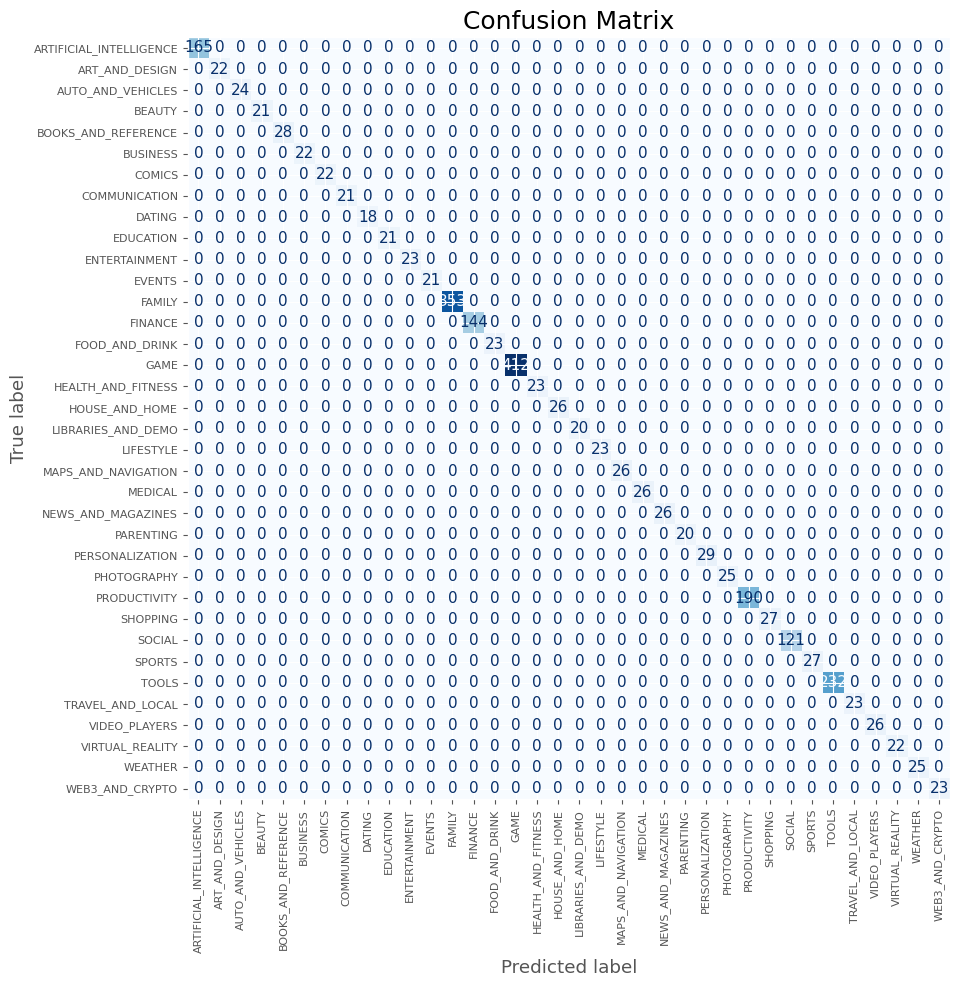

In [32]:
fig, ax = plt.subplots(figsize=(14, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_,
    ax=ax,
    cmap="Blues",
    colorbar=False,
    xticks_rotation=90
)

ax.set_title("Confusion Matrix", fontsize=18)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!!